In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Single PLot

In [2]:
def top_fraction(df, value_col, frac=0.20):
    """Return only the top frac of rows in df based on value_col (no grouping)."""
    threshold = df[value_col].quantile(1 - frac)
    return df[df[value_col] >= threshold]

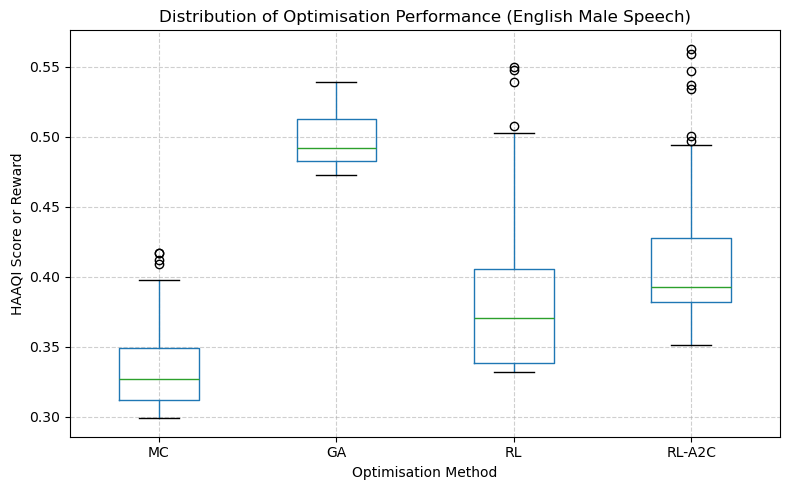

            mean     50%       std     cv
MC      0.332651  0.3270  0.027122  0.082
GA      0.497193  0.4920  0.018053  0.036
RL      0.381563  0.3705  0.048610  0.127
RL-A2C  0.410042  0.3930  0.045753  0.112


In [3]:

# === Load datasets ===
paths = {
    "GA": "Thesis.Related/Speech/Evo_Data_FullResults_202510301421_EnglishMale.csv",
    "MC": "Thesis.Related/Speech/MC_Data_FullResults_202510301447_EnglishMale.csv",
    "RL": "Thesis.Related/Speech/RL_Data_FullResults_202511051532_EnglishMale.csv",
    "RL-A2C": "Thesis.Related/Speech/RL_PPO_Data_FullResults_202511051532_EnglishMale.csv"
}

ga = pd.read_csv(paths["GA"])
mc = pd.read_csv(paths["MC"])
rl = pd.read_csv(paths["RL"])
a2c = pd.read_csv(paths["RL-A2C"])

# Read files
ga = ga[ga["score"] != 0]
ga = ga.iloc[:-60, :]
rl = rl.drop(columns=["update", "episode", "timestep"], errors="ignore")
a2c = a2c.drop(columns=["update", "episode", "timestep"], errors="ignore")

# Drop exact duplicate rows in all datasets
ga = ga.drop_duplicates()
mc = mc.drop_duplicates()
rl = rl.drop_duplicates()
a2c = a2c.drop_duplicates()

ga_top = top_fraction(ga, "score", 0.25)
mc_top = top_fraction(mc, "score", 0.25)
rl_top = top_fraction(rl, "reward", 0.25)
a2c_top = top_fraction(a2c, "reward", 0.25)

# Extract relevant performance data
data = {
    "MC": mc_top["score"],
    "GA": ga_top["score"],
    "RL": rl_top["reward"],
    "RL-A2C": a2c_top["reward"]
}

# Combine into single DataFrame
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data.items()]))

# === Plot boxplot ===
plt.figure(figsize=(8, 5))
df.boxplot()
plt.title("Distribution of Optimisation Performance (English Male Speech)")
plt.ylabel("HAAQI Score or Reward")
plt.xlabel("Optimisation Method")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# === Descriptive statistics ===
stats = df.describe().T
stats["cv"] = (stats["std"] / stats["mean"]).round(3)  # Coefficient of Variation
print(stats[["mean", "50%", "std", "cv"]])

In [ ]:
ga.size


In [ ]:
ga.shape, 

## Group Plot

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# === 1. Define paths and optimisers ===
data_dir = "Data/Speech/"  # adjust if needed
optimisers = {
    "MC": "MC_Data_FullResults_*_*.csv",
    "GA": "Evo_Data_FullResults_*_*.csv",
    "RL": "RL_Data_FullResults_*_*.csv"
}

# === 2. Helper: load and clean individual files ===
def load_one_file(filepath, optimiser):
    df = pd.read_csv(filepath)
    filename = os.path.basename(filepath)

    # Extract dataset name (e.g., EnglishMale, GermanMale)
    dataset = filename.split("_")[-1].replace(".csv", "")

    # --- Special handling for GA ---
    if optimiser == "GA":
        if "score" in df.columns:
            df = df[df["score"] != 0]          # remove zero scores
            if len(df) > 60:                   # remove last 60 if overrun
                df = df.iloc[:-60, :]
        else:
            raise ValueError(f"GA file missing 'score' column: {filename}")
    if optimiser == "RL" :
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")
        df.drop(columns=["update", "episode", "timestep"], errors="ignore")


    # --- General cleaning for all optimisers ---
    df = df.drop_duplicates()

    # --- Select correct metric ---
    if "score" in df.columns:
        value_col = "score"
    elif "reward" in df.columns:
        value_col = "reward"
    else:
        raise ValueError(f"No valid 'score' or 'reward' column in {filename}")

    # --- Label and return ---
    df["Optimiser"] = optimiser
    df["Dataset"] = dataset
    df["Value"] = df[value_col]
    return df[["Optimiser", "Dataset", "Value"]]

# === 3. Load all datasets automatically ===
all_dfs = []
for opt, pattern in optimisers.items():
    for filepath in glob.glob(os.path.join(data_dir, pattern)):
        try:
            all_dfs.append(load_one_file(filepath, opt))
        except Exception as e:
            print(f"⚠️ Skipped {filepath}: {e}")

df_all = pd.concat(all_dfs, ignore_index=True)




/tmp/ipykernel_161232/2941079288.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(


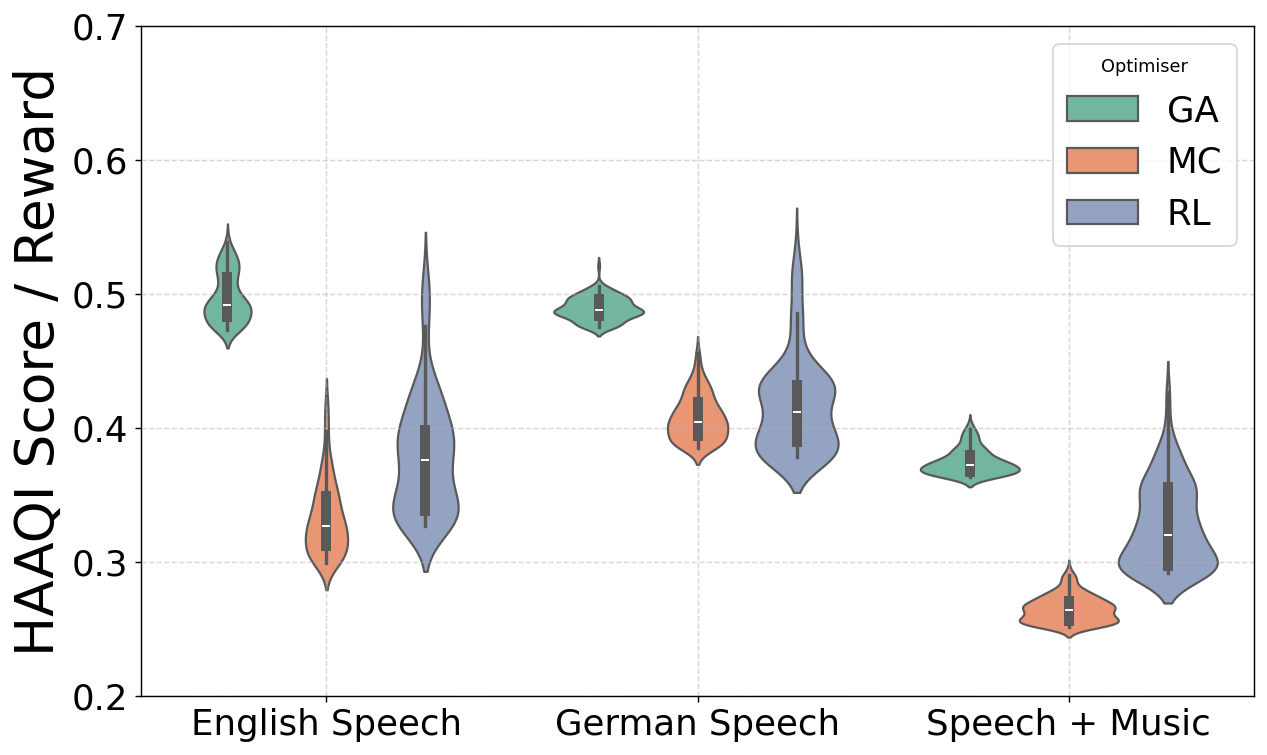

                             mean  median     std     cv
Dataset         Optimiser                               
EnglishMale     GA         0.4972  0.4920  0.0181  0.036
                MC         0.3327  0.3270  0.0271  0.081
                RL         0.3789  0.3760  0.0440  0.116
Germanspeech    GA         0.4892  0.4880  0.0085  0.017
                MC         0.4078  0.4045  0.0167  0.041
                RL         0.4177  0.4120  0.0362  0.087
SpeechwithMusic GA         0.3746  0.3720  0.0094  0.025
                MC         0.2649  0.2640  0.0099  0.037
                RL         0.3270  0.3200  0.0315  0.096


In [5]:
# === 4. Optional: keep only top 5% per optimiser/dataset ===
def top_fraction_per_group(df, frac=0.10):
    return df.groupby(["Optimiser", "Dataset"], group_keys=False).apply(
        lambda g: g[g["Value"] >= g["Value"].quantile(1 - frac)]
    )

df_top = top_fraction_per_group(df_all, frac=0.25)

# === 5. Plot grouped boxplots ===
plt.figure(figsize=(10,6),dpi=128)
#sns.boxplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
sns.violinplot(data=df_top, x="Dataset", y="Value", hue="Optimiser", palette="Set2")
#plt.title("Top 25% Optimisation Performance Across Datasets and Methods")
plt.ylabel("HAAQI Score / Reward", fontsize=30)
plt.ylim(0.20, 0.70)
plt.xlabel("", fontsize=24)
plt.xticks(
    ticks=range(3),  # number of categories
    labels=["English Speech", "German Speech", "Speech + Music"],
    fontsize=20
)
plt.yticks(fontsize=20)
plt.legend(title="Optimiser",fontsize=20)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# === 6. Summary stats ===
summary = df_top.groupby(["Dataset", "Optimiser"])["Value"].agg(["mean", "median", "std"]).round(4)
summary["cv"] = (summary["std"] / summary["mean"]).round(3)
print(summary)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Suppose you have all results in one df with 'Optimiser' and 'Value'
best = df_top.groupby("Optimiser")["Value"].max().sort_values(ascending=False)

plt.bar(best.index, best.values)
plt.title("Maximum Value Achieved per Optimiser")
plt.ylabel("Max HAAQI / Reward")
plt.show()

In [ ]:
top_mean = df_top.groupby("Optimiser")["Value"].apply(lambda x: x.nlargest(int(len(x)*0.05)).mean())

In [ ]:
top_mean

In [ ]:
import seaborn as sns
sns.ecdfplot(data=df_top, x="Value", hue="Optimiser")

In [ ]:
import seaborn as sns
sns.violinplot(data=df_top, x="Optimiser", y="Value", cut=0)